## 모델 평가 방법

본 노트북은 제출 후 바로 실행 가능하도록 구성되어 있습니다.  
다만, Colab의 기본 환경이 CPU로 설정되어 있어, **GPU로 변경해주시면 보다 원활하게 실행됩니다.**

> GPU 설정 방법은 아래 이미지를 통해 간단히 안내드립니다.

![GPU 설정 안내 1](https://i.ibb.co/yBnDjH18/1.png)  
![GPU 설정 안내 2](https://i.ibb.co/JwnQssB2/2.png)

In [1]:
!gdown --id 1UZr2WcAbasxEr1mx2Bcxq8wnvfloY516 --output fft_result_dataset.pickle # FFT로 변환한 데이터셋 다운로드
print("데이터셋 다운로드 완료")
!gdown --id 1VLplW5TCnxG8uBcZP9x4Ck06wv3ZYvMv --output fft_model.h5 # 모델 다운로드
print("모델 다운로드 완료")

import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

model = load_model("./fft_model.h5") # 모델 로드
model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

#모델 요약 정보 보기
"""model2.summary()"""

# 데이터셋 로드
file_path = "./fft_result_dataset.pickle"
with open(file_path,"rb") as fr:
    data = pickle.load(fr)

x = data["x"]
y = data["y"]

# 학습데이터, 테스트 데이터 분리
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=777, shuffle=True)

# 모델 정확도 검증
score1 = model.evaluate(np.abs(x), y)
print(f"모델 정확도(전체 데이터) : {score1[1] * 100 : .2f}%")

score2 = model.evaluate(np.abs(train_x), train_y)
print(f"모델 정확도(학습 데이터) : {score2[1] * 100 : .2f}%")

score3 = model.evaluate(np.abs(test_x), test_y)
print(f"모델 정확도(테스트 데이터) : {score3[1] * 100 : .2f}%")

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1UZr2WcAbasxEr1mx2Bcxq8wnvfloY516
From (redirected): https://drive.google.com/uc?id=1UZr2WcAbasxEr1mx2Bcxq8wnvfloY516&confirm=t&uuid=1a85eca4-86ae-4692-8870-0a59d7b69820
To: /content/fft_result_dataset.pickle
100% 2.32G/2.32G [00:18<00:00, 123MB/s] 
데이터셋 다운로드 완료
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1VLplW5TCnxG8uBcZP9x4Ck06wv3ZYvMv
From (redirected): https://drive.google.com/uc?id=1VLplW5TCnxG8uBcZP9x4Ck06wv3ZYvMv&confirm=t&uuid=7d93198b-fb61-4b08-b73e-0cabcb972fb2

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.9348 - loss: 3333858.2500
모델 정확도(전체 데이터) :  93.86%
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.9879 - loss: 732288.5000
모델 정확도(학습 데이터) :  97.41%
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 0.8583 - loss: 9544355.0000
모델 정확도(테스트 데이터) :  85.71%


# 아래는 개발 한 전체 소스코드 입니다

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install keras scikit-learn numpy pandas scipy

In [ ]:
!pip install --upgrade keras tensorflow==2.18.0

In [ ]:
!pip install kagglehub

In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [ ]:
!pip install --upgrade --pre scikit-learn --upgrade-strategy eager

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

import kagglehub
from pathlib import Path
import scipy.io.wavfile as sci_wav
import keras

from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

# plt.rc('font', family='NanumBarunGothic')

print("Hello World")

Hello World


# DFT 구현

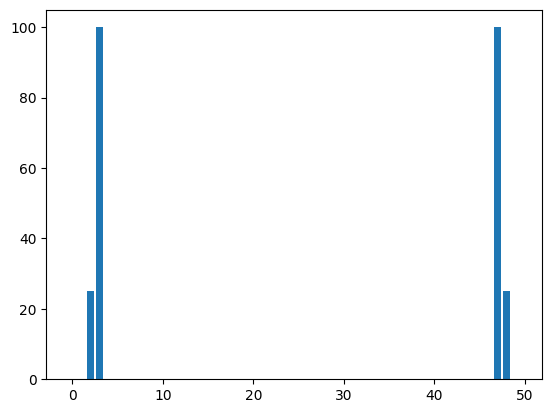

In [4]:
t = np.linspace(0, 2 * np.pi, 50, endpoint=False)
signal = np.sin(2 * t) + 4 * np.cos(3 * t)

N = len(signal)

x_list = []

for k in range(0, N):
    print("%06d / %06d" % (k, N), end="\r")
    X = 0
    for n, x_n in enumerate(signal):
        X += x_n * np.exp(-2j * np.pi * k * n / N)
    x_list.append(X)

plt.bar(np.arange(N), np.abs(x_list))
plt.show()

In [ ]:
ix_list = []

for n in range(N):
    X = 0

    for k, x_k in enumerate(x_list):
        X += x_k * np.exp(2j * np.pi * k * n / N)
    ix_list.append(X / N)

ix_list = np.array(ix_list)
plt.plot(ix_list.real)

# FFT 구현

In [ ]:
def fft(signal):
    N = len(signal)
    half = N // 2

    if(N == 1):
        return signal

    X_even = fft(signal[::2])
    X_odd = fft(signal[1::2])


    W = np.exp(-2j * np.pi * np.arange(N) / N)
    new_signal = np.zeros_like(signal, dtype=complex)

    new_signal[:half] = X_even + W[:half] * X_odd
    new_signal[half:] = X_even - W[:half] * X_odd

    return new_signal

### FFT 검증

In [ ]:
dataset_path = kagglehub.dataset_download("mmoreaux/audio-cats-and-dogs")

In [ ]:
root = Path(dataset_path)

cat_audio_path = list(root.glob("cats_dogs/train/cat/*.wav"))[0]
signal = sci_wav.read(cat_audio_path)[1]

padding_length = 1 << (len(signal) - 1).bit_length()

signal = np.pad(signal, (0, padding_length - len(signal)), mode="constant")

my_fft_result = fft(signal)
numpy_fft_result = np.fft.fft(signal)

same_verification = np.allclose(my_fft_result, numpy_fft_result)
print(f"FFT의 결과 {same_verification}")

# 오디오 분류

In [ ]:
dataset_path = kagglehub.dataset_download("mmoreaux/audio-cats-and-dogs")

print("Path to dataset files:", dataset_path)

100%|██████████| 97.0M/97.0M [00:01<00:00, 67.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mmoreaux/audio-cats-and-dogs/versions/5


In [ ]:
def signal_padding(signal, max_len):
    if len(signal) >= max_len:
        return signal[:max_len]
    else:
        return np.pad(signal, (0, max_len - len(signal)), mode="constant")

In [ ]:
root = Path(dataset_path)
cat_audios_path = list(root.glob("cats_dogs/train/cat/*.wav")) + list(root.glob("cats_dogs/test/cats/*.wav"))
dog_audios_path = list(root.glob("cats_dogs/train/dog/*.wav")) + list(root.glob("cats_dogs/test/test/*.wav"))

cat_audios = [len(sci_wav.read(path)[1]) for path in cat_audios_path]
max_length = max(cat_audios)
max_length = 1 << (max_length - 1).bit_length()

print("고양이 소리 개수 : ", len(cat_audios_path))
print("강아지 소리 개수 : ", len(dog_audios_path))

x = []
y = []

for path in cat_audios_path:
    sample_rate, signal = sci_wav.read(path)
    sianal = signal_padding(signal, max_length)
    x.append(sianal)
    y.append(np.array([1, 0]))

for path in dog_audios_path:
    sample_rate, signal = sci_wav.read(path)
    sianal = signal_padding(signal, max_length)
    x.append(sianal)
    y.append(np.array([0, 1]))

x = np.array(x)
y = np.array(y)

print(x.shape)
print(y.shape)

고양이 소리 개수 :  164
강아지 소리 개수 :  113
(277, 524288)
(277, 2)


In [ ]:
plt.plot(x[0])
plt.show()

In [ ]:
fft_result = fft(x[0])
plt.plot(np.abs(fft_result))
plt.show()

In [ ]:
fft_result = list(map(fft, x))
fft_result = np.array(fft_result)
fft_result.shape

In [ ]:
fft_result = list(map(fft, test_x))
fft_result = np.array(fft_result)
fft_result.shape

In [ ]:
import pickle

data = {
    "x": fft_result,
    "y" : y
}

with open('fft_result_dataset.p', 'wb') as f:
    pickle.dump(data, f)

### 모델 학습

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=777, shuffle=True)

print(f"전체 데이터 x: {x.shape}")
print(f"전체 데이터 y: {y.shape}")

print(f"train_x: {train_x.shape}")
print(f"train_y: {train_y.shape}")

print(f"test_x: {test_x.shape}")
print(f"test_y: {test_y.shape}")

전체 데이터 x: (277, 524288)
전체 데이터 y: (277, 2)
train_x: (193, 524288)
train_y: (193, 2)
test_x: (84, 524288)
test_y: (84, 2)


In [ ]:
model1 = Sequential([
    Input(shape=(x.shape[1], ), name = "Input"),
    Dense(200, activation="relu", name = "Hidden_0"),
    Dense(100, activation="relu", name = "Hidden_1"),
    Dense(70, activation="relu", name = "Hidden_2"),
    Dense(50, activation="relu", name = "Hidden_3"),
    Dense(20, activation="relu", name = "Hidden_4"),
    Dense(5, activation="relu", name = "Hidden_5"),
    Dense(2, activation="softmax", name = "Output")
])

model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_0 (Dense)                │ (None, 200)            │   104,857,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_1 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 70)             │         7,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_3 (Dense)                │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_4 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_5 (Dense)                │ (None, 5)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,889,657 (400.12 MB)

 Trainable params: 104,889,657 (400.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
history_model_1 = model1.fit(np.abs(train_x), train_y, epochs=100, batch_size=300, validation_split=0.25)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4167 - loss: 238.3990 - val_accuracy: 0.3061 - val_loss: 13160.9795
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4167 - loss: 10301.2617 - val_accuracy: 0.6531 - val_loss: 33254.0820
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step - accuracy: 0.5903 - loss: 29608.3789 - val_accuracy: 0.7347 - val_loss: 18786.7852
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.6597 - loss: 17034.5312 - val_accuracy: 0.3061 - val_loss: 28931.4590
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.4236 - loss: 18543.3047 - val_accuracy: 0.4490 - val_loss: 14915.0869
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5556 - loss: 11372.4580 - val_accuracy: 0.3265 - val_loss: 13383.0381
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5208 - loss: 9079.1904 - val_accuracy: 0.4082 - val_loss: 17366.3105
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy

In [ ]:
score = model1.evaluate(test_x, test_y)

print(f"모델 1 오차 : {score[0]}")
print(f"모델 1 정확도 : {score[1] * 100 : .2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4743 - loss: 1436.7137
모델 1 오차 : 1101.257568359375
모델 1 정확도 :  46.43%


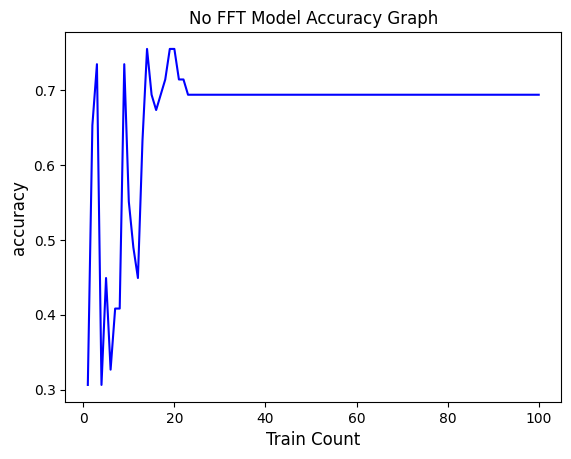

<Figure size 640x480 with 0 Axes>

In [ ]:
loss_train = history_model_1.history["loss"]
loss_val = history_model_1.history["val_loss"]
val_accuracy = history_model_1.history["val_accuracy"]

epoch = range(1, len(loss_val) + 1)

plt.plot(epoch, val_accuracy, "b-")
plt.xlabel("Train Count").set_size(12)
plt.ylabel("accuracy").set_size(12)
plt.title("No FFT Model Accuracy Graph")

plt.show()
plt.savefig("No FFT Model Accuracy Graph.png")

### FFT 사용 버전

In [ ]:
import pickle

file_path = "/content/drive/MyDrive/INU/2025 _2학년/0. 1학기 수업/컴퓨터 알고리즘/fft_result_dataset.p"

with open(file_path,"rb") as fr:
    data = pickle.load(fr)

x = data["x"]
y = data["y"]

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=777, shuffle=True)

print(f"전체 데이터 x: {x.shape}")
print(f"전체 데이터 y: {y.shape}")

print(f"train_x: {train_x.shape}")
print(f"train_y: {train_y.shape}")

print(f"test_x: {test_x.shape}")
print(f"test_y: {test_y.shape}")

전체 데이터 x: (277, 524288)
전체 데이터 y: (277, 2)
train_x: (193, 524288)
train_y: (193, 2)
test_x: (84, 524288)
test_y: (84, 2)


In [ ]:
model2 = Sequential([
    Input(shape=(x.shape[1], ), name = "Input"),
    Dense(200, activation="relu", name = "Hidden_0"),
    Dense(100, activation="relu", name = "Hidden_1"),
    Dense(70, activation="relu", name = "Hidden_2"),
    Dense(50, activation="relu", name = "Hidden_3"),
    Dense(20, activation="relu", name = "Hidden_4"),
    Dense(5, activation="relu", name = "Hidden_5"),
    Dense(2, activation="softmax", name = "Output")
])

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_0 (Dense)                │ (None, 200)            │   104,857,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_1 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 70)             │         7,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_3 (Dense)                │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_4 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_5 (Dense)                │ (None, 5)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,889,657 (400.12 MB)

 Trainable params: 104,889,657 (400.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
history_model_2 = model2.fit(np.abs(train_x), train_y, epochs=100, batch_size=300, validation_split=0.25)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.4167 - loss: 229975.6719 - val_accuracy: 0.6735 - val_loss: 10359560.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.5694 - loss: 10657778.0000 - val_accuracy: 0.8367 - val_loss: 6225512.5000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step - accuracy: 0.7361 - loss: 6074864.0000 - val_accuracy: 0.8163 - val_loss: 7215360.5000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step - accuracy: 0.7847 - loss: 6616192.0000 - val_accuracy: 0.9388 - val_loss: 5582238.5000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8889 - loss: 3626563.5000 - val_accuracy: 0.9388 - val_loss: 4952988.5000
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step - accuracy: 0.8750 - loss: 3927304.0000 - val_accuracy: 0.9184 - val_loss: 3707618.5000
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9306 - loss: 1533707.2500 - val_accuracy: 0.8980 - val_loss: 4649067.0000
Epoch 8/100
1/1 ━━━━━━━━━━━━━

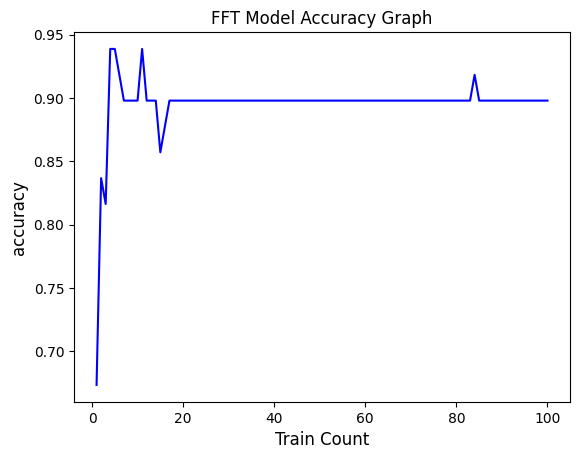

<Figure size 640x480 with 0 Axes>

In [ ]:
# plt.rc('font', family='NanumBarunGothic')

loss_train = history_model_2.history["loss"]
loss_val = history_model_2.history["val_loss"]
val_accuracy = history_model_2.history["val_accuracy"]

epoch = range(1, len(loss_val) + 1)

plt.plot(epoch, val_accuracy, "b-")
plt.xlabel("Train Count").set_size(12)
plt.ylabel("accuracy").set_size(12)
plt.title("FFT Model Accuracy Graph")

plt.show()
plt.savefig("FFT Model Accuracy Graph.png")

In [ ]:
score = model2.evaluate(np.abs(test_x), test_y)

print(f"모델 2 오차 : {score[0] : .2f}")
print(f"모델 2 정확도 : {score[1] * 100 : .2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.8583 - loss: 9544355.0000
모델 2 오차 :  9402046.00
모델 2 정확도 :  85.71%


In [ ]:
model2.save("fft_model2.h5")

In [ ]:
from google.colab import files
files.download("fft_model2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("history_model_2.p")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>